To evaluate PyChemelt's performance on an experimental dataset the DNAJB6b dataset from *Fricke et al.*<sup>1</sup> was processed and used. This datasets provides 17 thermal denaturation curves with differing concentrations of GuHCL. This dataset was thus used to fit the parameters in a 2 dimensional fashion to the curves regarding temperature and chemical denaturation. <br>


<sup>1</sup> Fricke, Celia, et al. "On the thermal and chemical stability of DNAJB6b and its globular domains." Biophysical Chemistry 320 (2025): 107401.*

This notebook is possible thanks to the publication of the data and associated code.
See https://data.dtu.dk/articles/code/Fitting_of_thermal_and_chemical_denaturation/27679716

In [1]:
from dataclasses import dataclass
from pychemelt import Monomer

import numpy as np
import pandas as pd

from plotly.subplots import make_subplots
from pychemelt.utils.processing import (
    get_colors_from_numeric_values,
    combine_sequences
)

from pychemelt.utils.plotting import *
import plotly.graph_objs as go

from scripts import display_figure_static

In [2]:
@dataclass
class pantasample:
    T: np.ndarray
    f330: np.ndarray
    f350: np.ndarray
    denaturant: float

df=pd.read_csv('../data/nanoDSF_B6.csv', sep = '\t')

# Denaturant concentrations in M
denaturants = [0, 0.08, 0.4, 0.8, 1.2, 1.6, 2, 2.4, 2.8, 3.2, 3.6, 4, 4.4, 4.8, 5.2, 5.6, 6, 6.4]

B6 = [] # List for storing unfolding measurements
for i in range(18):

    temperature = df[df.columns[i*12]].values + 273.15  # Convert to Kelvin

    B6.append(pantasample(df[df.columns[i*12]].values, df[df.columns[i*12+9]].values, df[df.columns[i*12+5]].values, denaturants[i])) 

In [3]:
sample = Monomer()

signal_dic = {}
temp_dic = {}

# Create a signal matrix from each B6 f350 array
signal_matrix = np.array([b6.f350 for b6 in B6])  
temp_matrix = np.array([b6.T for b6 in B6]) 

assert (temp_matrix.shape == signal_matrix.shape)  # Should be True

sample.signal_dic['350nm'] = signal_matrix
sample.temp_dic['350nm'] = temp_matrix

# Create a signal matrix from each B6 f330 array
signal_matrix = np.array([b6.f330 for b6 in B6])  
temp_matrix = np.array([b6.T for b6 in B6]) 

assert (temp_matrix.shape == signal_matrix.shape)  # Should be True

sample.signal_dic['330nm'] = signal_matrix
sample.temp_dic['330nm'] = temp_matrix

conditions = [b6.denaturant for b6 in B6]
sample.conditions = conditions

sample.set_signal(['350nm','330nm'])

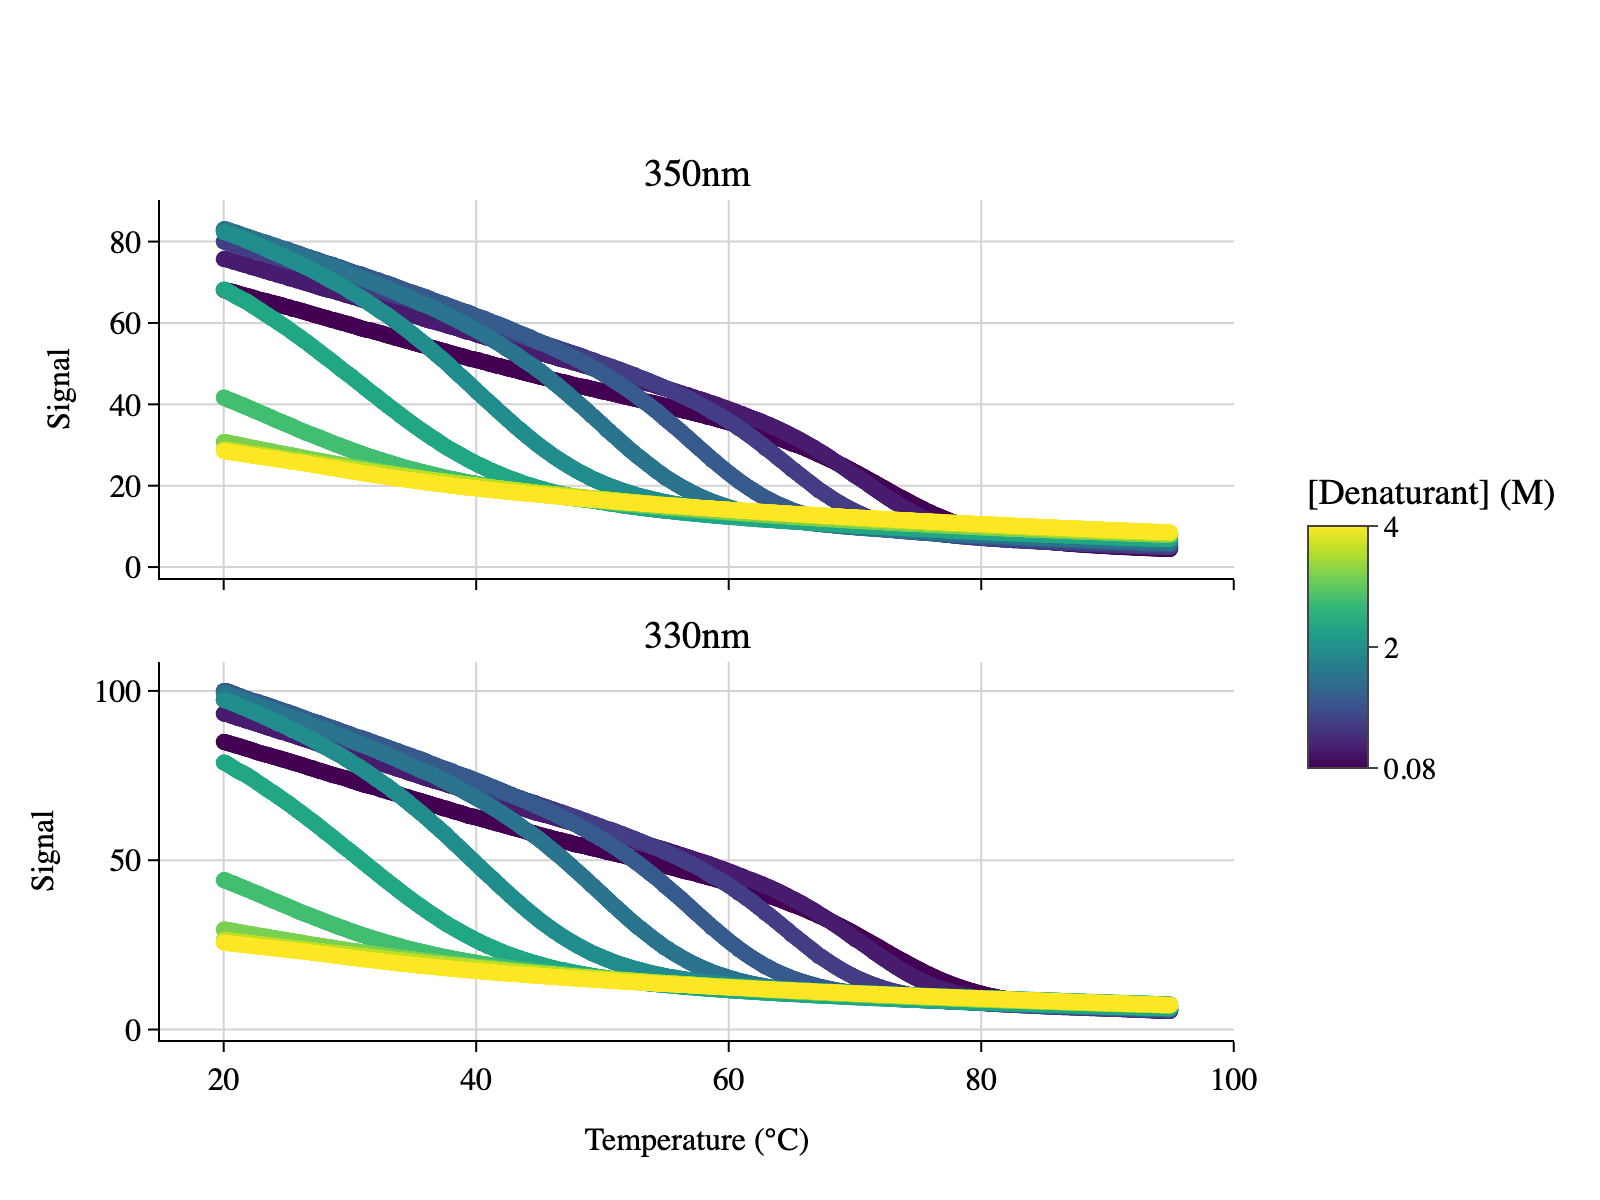

In [4]:

sample.set_denaturant_concentrations()
selected = [False]*1 + [True] * 11 + [False] * 6
sample.select_conditions(selected,normalise_to_global_max=True)
sample.estimate_derivative()
sample.expand_multiple_signal()

fig = plot_unfolding(sample)
display_figure_static(fig)

In [5]:
sample.global_min_temp = 20
sample.global_max_temp = 95
sample.expand_multiple_signal()

sample.estimate_baseline_parameters(
        native_baseline_type='linear',
        unfolded_baseline_type='exponential'
    )

sample.fit_thermal_unfolding_local()
sample.n_residues = 150 # For an initial guess of Cp, we need to set the number of residues in the sample
sample.guess_Cp()

In [6]:
# Do a fitting with global thermodynamic parameters, but local intercept terms and local slope terms
sample.fit_thermal_unfolding_global()

In [7]:
# Do a fitting with global thermodynamic parameters, local intercept terms and global slope terms
sample.fit_thermal_unfolding_global_global()

In [8]:
# Do a fitting with global thermodynamic parameters, global intercept terms and global slope terms
sample.fit_thermal_unfolding_global_global_global()

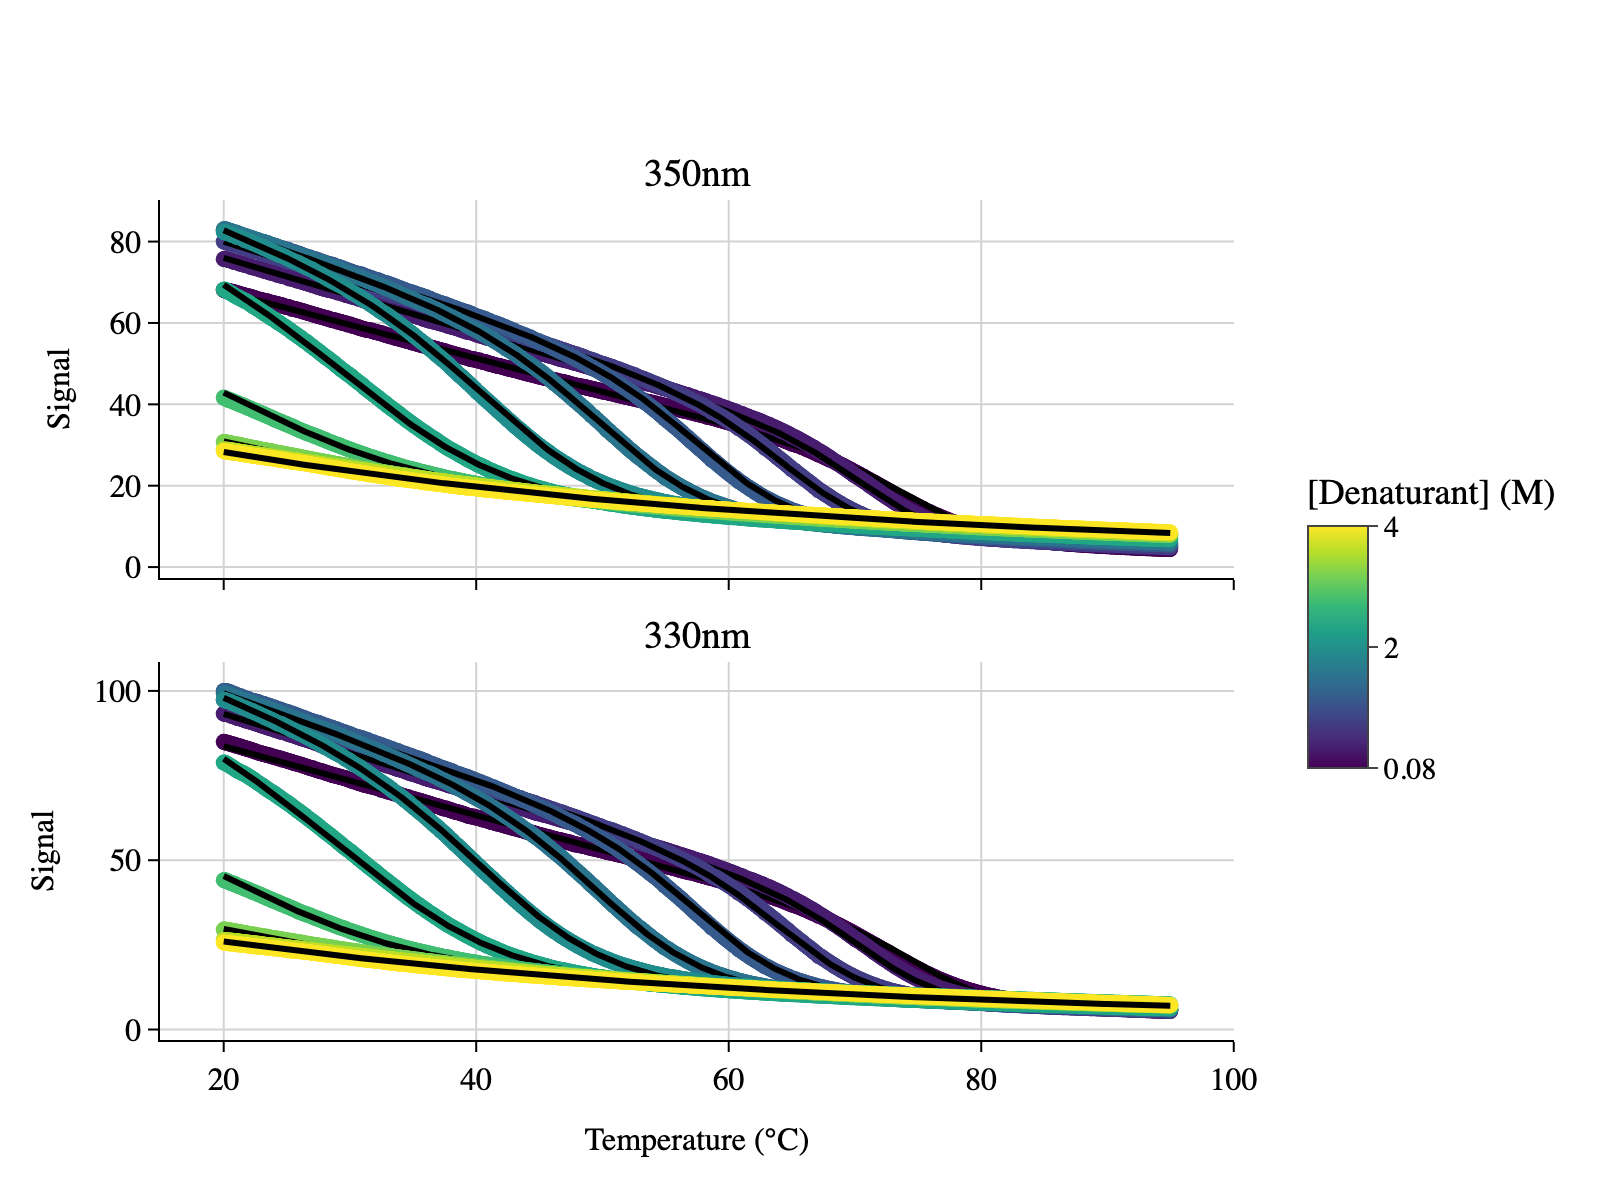

In [9]:
fig = plot_unfolding(sample)
display_figure_static(fig,height=600)

In [10]:
sample.create_fit_report()
print(sample.fit_report)

[[Fit Statistics]]
    # fitting method   = least_squares
    # function evals   = 436
    # data points      = 20328
    # variables        = 28
    chi-square         = 3274.08170
    reduced chi-square = 0.16128481
    Akaike info crit   = -37062.1517
    Bayesian info crit = -36840.3986
[[Variables]]
    Tm:     350.678188 +/- 0.01542246 (0.00%) (init = 350.3466)
    DHm:    75.4300211 +/- 0.11311477 (0.15%) (init = 71.65058)
    Cp0:    0.92719414 +/- 0.00242075 (0.26%) (init = 0.9222737)
    m0:     3.00242678 +/- 0.00379105 (0.13%) (init = 2.891716)
    p2N_0:  83.1031311 +/- 0.29914463 (0.36%) (init = 46.28011)
    p2N_1:  102.671007 +/- 0.36890038 (0.36%) (init = 52.18226)
    p2U_0: -0.00204489 +/- 0.06175802 (3020.12%) (init = -0.204489)
    p2U_1:  1.93925870 +/- 0.06089824 (3.14%) (init = 0.6604817)
    p3N_0: -1.06417870 +/- 0.00359864 (0.34%) (init = -0.876494)
    p3N_1: -1.32809001 +/- 0.00446321 (0.34%) (init = -1.095198)
    p3U_0:  22.7395892 +/- 0.06478062 (0.28%) 

In [11]:
# Estimate the asymmetric confidence intervals for the fitted parameters using the profile likelihood method
sample.calculate_confidence_intervals(percentage=0.95)

ci_df = sample.ci_df.copy()

# Conver lower_CI in value - lower_CI and upper_CI in value - upper_CI
ci_df["Lower_CI_95.0%"] = -(ci_df["Value"] - ci_df["Lower_CI_95.0%"])
ci_df["Upper_CI_95.0%"] = -(ci_df["Value"] - ci_df["Upper_CI_95.0%"])
ci_df

,Parameter,Lower_CI_95.0%,Value,Upper_CI_95.0%
0,Tm (°C),-0.007,77.528,0.008
1,ΔHm (kcal / mol),-0.008,75.430,0.008
2,ΔCp (kcal / mol / °C),-0.000,0.927,0.001
3,m-value (kcal / mol / M),-0.000,3.002,0.001


In [12]:
# Print it in joules per mole
report_joules = sample.ci_df.copy()
# Add 273.15 to the first row, after the first column, which is the parameter name
report_joules.iloc[0,1:] = report_joules.iloc[0,1:] + 273.15
# Multiply the second, third and fourth rows by 4.184 * 1000
report_joules.iloc[1,1:] = report_joules.iloc[1,1:] * 4.184 * 1000
report_joules.iloc[2,1:] = report_joules.iloc[2,1:] * 4.184 * 1000
report_joules.iloc[3,1:] = report_joules.iloc[3,1:] * 4.184 * 1000
report_joules['Parameter'] = ['Tm (K)', 'Delta H (J/mol)', 'Delta Cp (J/mol/K)', 'm-value (J/mol/M)']
print(report_joules)

            Parameter  Lower_CI_95.0%       Value  Upper_CI_95.0%
0              Tm (K)         350.671     350.678         350.686
1     Delta H (J/mol)      315565.648  315599.120      315632.592
2  Delta Cp (J/mol/K)        3878.568    3878.568        3882.752
3   m-value (J/mol/M)       12560.368   12560.368       12564.552


In [13]:
# Save the fitted thermodynamic parameters

Tm = sample.params_df.iloc[0,1]
dH = sample.params_df.iloc[1,1]
Cp = sample.params_df.iloc[2,1]
m = sample.params_df.iloc[3,1]
dG = sample.dg_df.iloc[50,0]

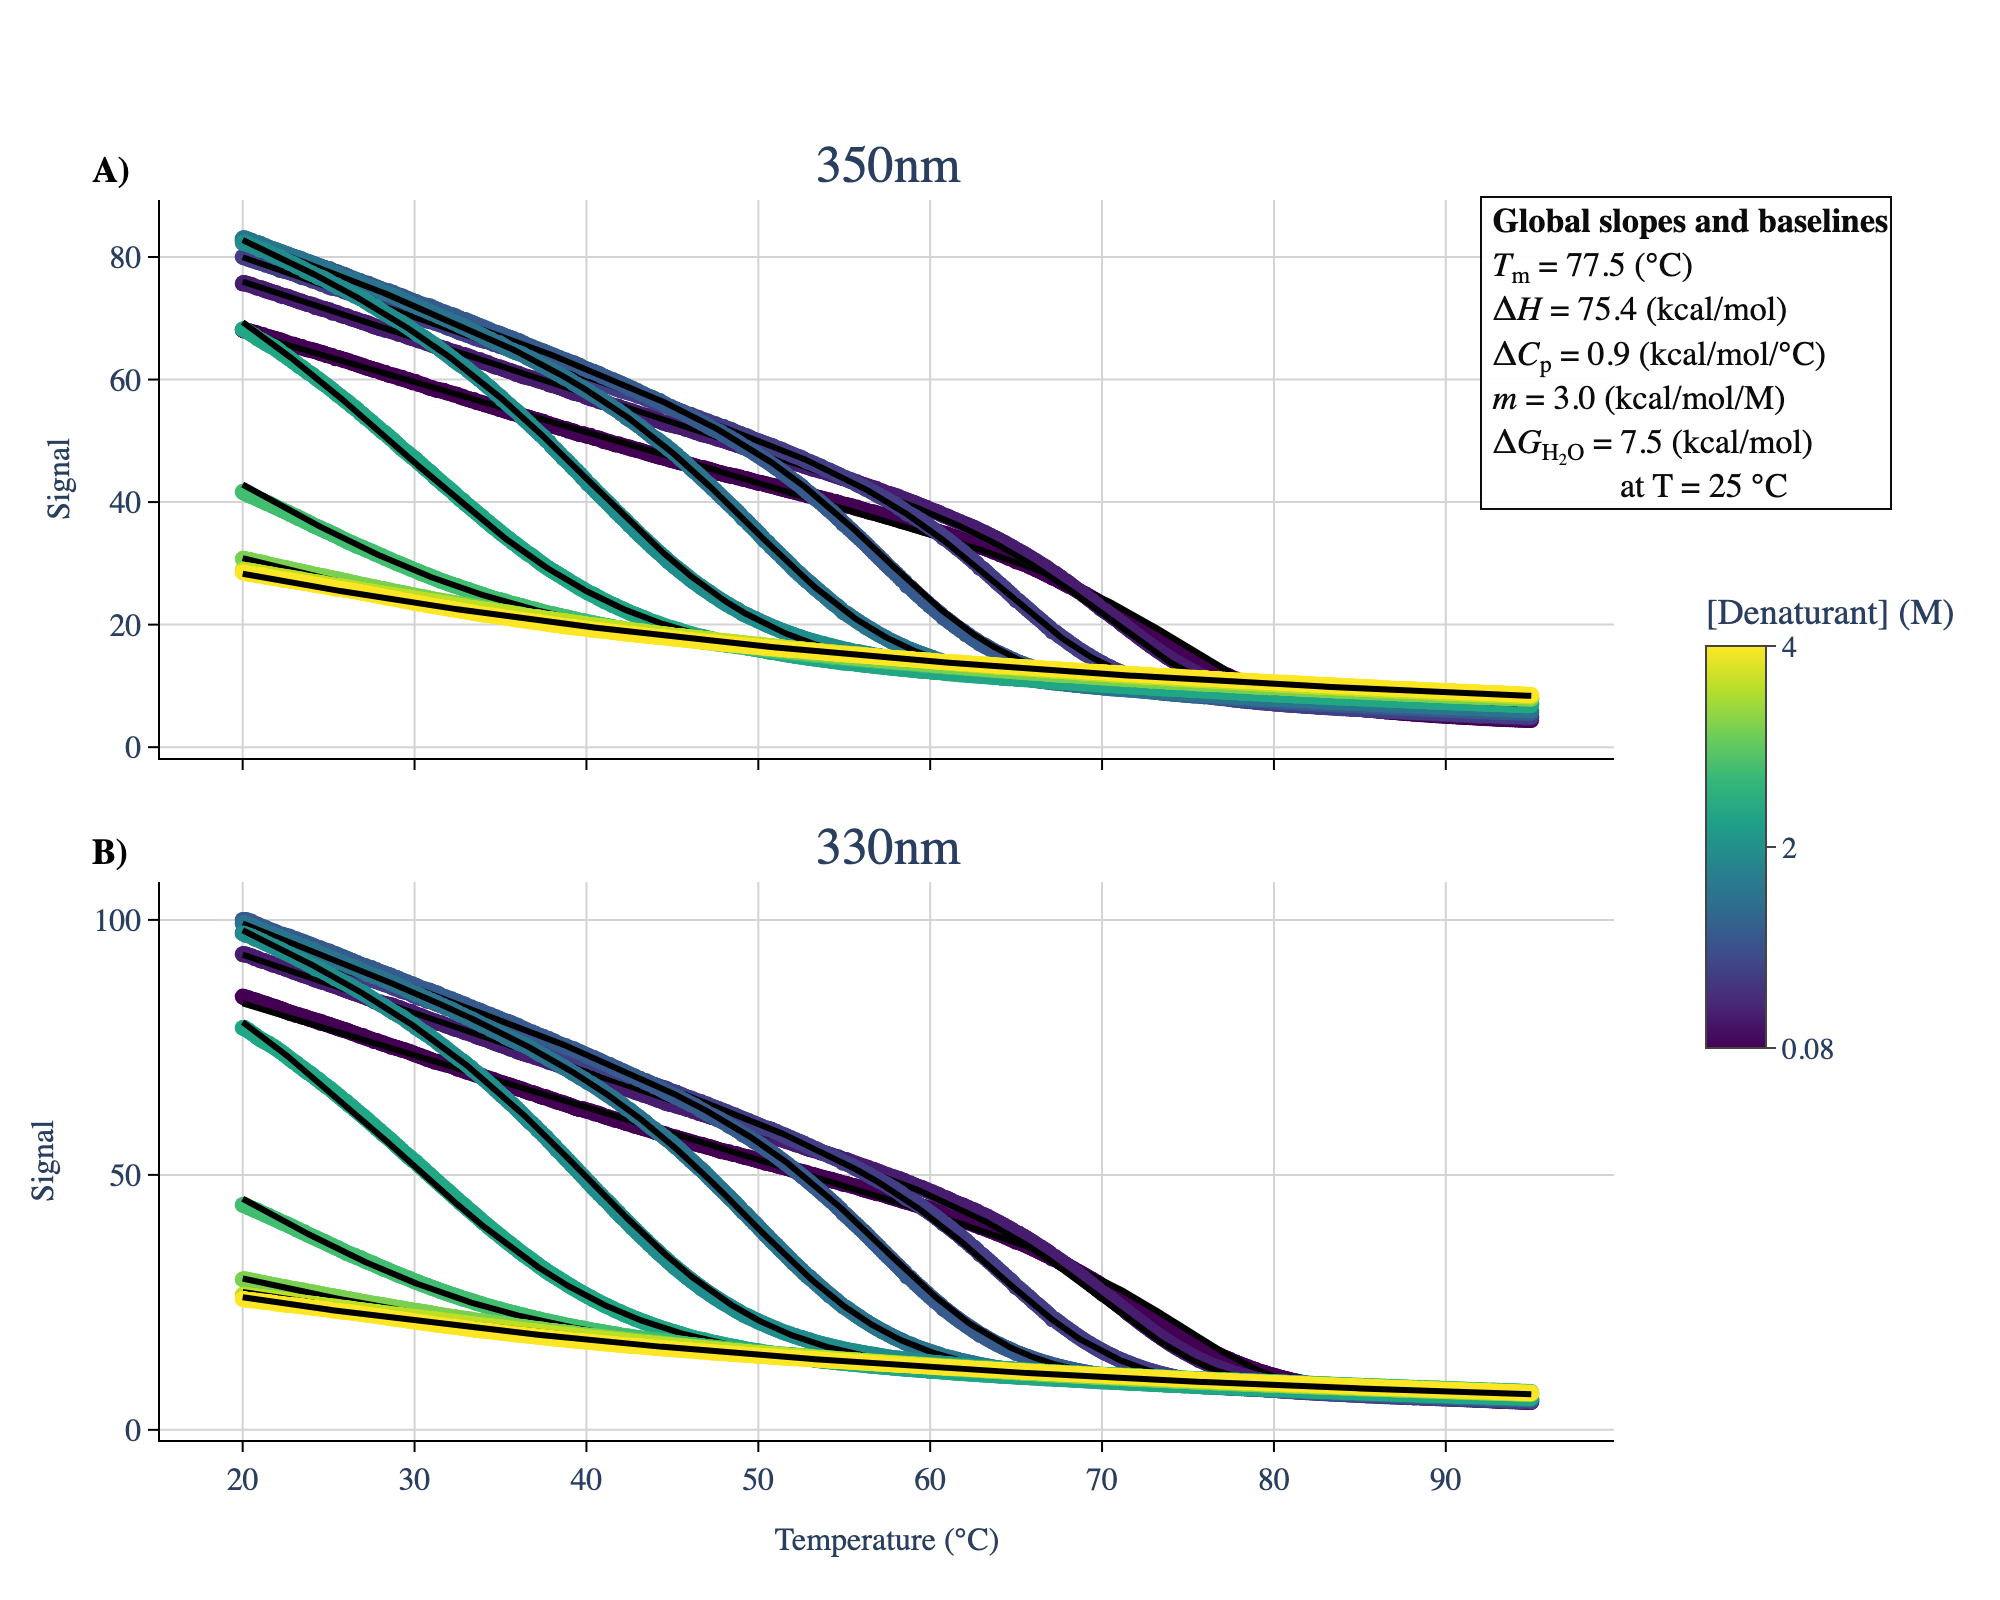

In [14]:
# modifying the plot_unfolding method for the generation of the figure

# Set defaults for configuration objects
plot_config = PlotConfig()
axis_config = AxisConfig()
layout_config = LayoutConfig()
legend_config = LegendConfig()

# Extract the minimum and maximum denaturation concentration
concs = sample.denaturant_concentrations

min_conc = np.min(concs)
max_conc = np.max(concs)

colors = get_colors_from_numeric_values(concs, min_conc, max_conc)

n_subplots = sample.nr_signals

# Set number of rows: 2 if less than 8 plots, else 3
nrows = 2 if n_subplots < 9 else 3
nrows = min(nrows, n_subplots)  # Do not exceed the number of plots - case n equal 1

ncols = int(np.ceil(n_subplots / nrows))

row_arr = np.arange(1, nrows + 1)
col_arr = np.arange(1, ncols + 1)
# Row and column counters for subplotting
row_col_info = combine_sequences(row_arr, col_arr)

subplot_titles = sample.signal_names

fig = make_subplots(
    rows=nrows,
    cols=ncols,
    shared_xaxes=True,
    shared_yaxes=False,
    vertical_spacing=layout_config.vertical_spacing,
    subplot_titles=subplot_titles)

subplot_idx = 0

fittings_done = sample.global_fit_params is not None

ys_fit = None

nr_den = sample.nr_den

for i in range(n_subplots):

    row = row_col_info[subplot_idx][0]
    col = row_col_info[subplot_idx][1]

    ys_fit = sample.predicted_lst_multiple[i]
    xs     = sample.temp_lst_expanded[i*nr_den:(i+1)*nr_den]
    ys     = sample.signal_lst_expanded[i*nr_den:(i+1)*nr_den]

    for j,conc in enumerate(concs):

        color = colors[j]

        x = xs[j]
        y = ys[j]

        fig.add_trace(
            go.Scatter(
                x=x, y=y, mode='markers',
                marker=dict(size=plot_config.marker_size, color=color),
                name=f'{conc:.2f} M',
                showlegend=False
            ),
            row=row, col=col
        )

        # count np.nans in ys_fit
        ys_fit_j = ys_fit[j]

        fig.add_trace(
            go.Scatter(
                x=x, y=ys_fit_j, mode='lines',
                line=dict(color='black', width=plot_config.line_width),
                showlegend=False,
                hoverinfo='skip',
                hovertemplate=None
            ),
            row=row, col=col
        )

    subplot_idx += 1

    # Add an annotation inside the subplot showing the subfigure numeration
    axis_index = i + 1
    # Plotly expects 'x domain'/'y domain' (no '1') for the first axis; for others use 'xN domain'
    if axis_index == 1:
        xref = 'x domain'
        yref = 'y domain'
    else:
        xref = f'x{axis_index} domain'
        yref = f'y{axis_index} domain'

    # Add panel label (A, B, C, etc.)
    panel_label = chr(65 + i)  # 65 is ASCII code for 'A'
    fig.add_annotation(
        x=-0.05,
        y=1.1,
        xref=xref,
        yref=yref,
        text=f'<b>{panel_label})</b>',
        showarrow=False,
        align='left',
        font=dict(size=18, color='black')
    )

# Update subplot layout with white background and axis styling
fig.update_layout(
    font_family="Roboto",
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(font=dict(size=plot_config.font_size - 1))
)

for i in range(n_subplots):

    row = row_col_info[i][0]
    col = row_col_info[i][1]

    # Set the x-axis title only for the last row
    title_text_x = 'Temperature (°C)' if row == nrows else ''

    # Set the y-axis title only for the first column
    title_text_y = 'Signal' if col == 1 else ''

    fig.update_xaxes(
        title_text=title_text_x,
        showgrid=axis_config.showgrid_x,
        gridwidth=axis_config.gridwidth,
        gridcolor='lightgray',
        showline=True,
        linewidth=axis_config.linewidth,
        linecolor='black',
        zeroline=False,
        tickcolor='black',
        ticks="outside",
        tickwidth=axis_config.tickwidth,
        ticklen=axis_config.ticklen,
        title_font_size=plot_config.font_size,
        tickfont_size=plot_config.font_size,
        col = col,
        row = row
    )

    fig.update_yaxes(
        title_text=title_text_y,
        showgrid=axis_config.showgrid_y,
        gridwidth=axis_config.gridwidth,
        gridcolor='lightgray',
        showline=True,
        linewidth=axis_config.linewidth,
        linecolor='black',
        zeroline=False,
        tickcolor='black',
        ticks="outside",
        tickwidth=axis_config.tickwidth,
        ticklen=axis_config.ticklen,
        title_font_size=plot_config.font_size,
        tickfont_size=plot_config.font_size,
        nticks = axis_config.n_y_axis_ticks,
        col=col,
        row=row
    )

# Build colorbar dict using legend_config values (orientation and x/y position)
# Choose sensible anchors depending on orientation
_xanchor = 'center' if legend_config.color_bar_orientation == 'h' else 'left'
_yanchor = 'top'    if legend_config.color_bar_orientation == 'h' else 'middle'

colorbar_dict = dict(
    title='[Denaturant] (M)',
    tickvals=[min_conc, 0.5*(min_conc + max_conc), max_conc],
    ticktext=[f"{min_conc:.2g}", f"{(min_conc + max_conc) * 0.5:.2g}", f"{max_conc:.2g}"],
    len=legend_config.color_bar_length,
    outlinewidth=1,
    ticks='outside',
    tickfont=dict(size=plot_config.font_size - 1),
    orientation=legend_config.color_bar_orientation,
    x=legend_config.color_bar_x_pos,
    y=legend_config.color_bar_y_pos,
    xanchor=_xanchor,
    yanchor=_yanchor
)


fig.add_trace(
    go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(
            colorscale='Viridis',
            cmin=min_conc,
            cmax=max_conc,
            colorbar=colorbar_dict
        ),
        showlegend=False,
        hoverinfo='skip'
    ),
    row=1, col=1
)


# Adding the thermodynamic parameters of the fitted formula 
fig.add_annotation(
    x=legend_config.color_bar_x_pos ,
    y=legend_config.color_bar_y_pos + 0.25,  # move ABOVE colorbar
    xref="paper",
    yref="paper",
    xanchor="center",
    yanchor="bottom",
    showarrow=False,
    align="left",
    text=(
        " <b>Global slopes and baselines</b><br>"
        f" <i>T</i><sub>m</sub> = {Tm:.1f} (°C) <br>"
        f" Δ<i>H</i> = {dH:.1f} (kcal/mol) <br>"
        f" Δ<i>C</i><sub>p</sub> = {Cp:.1f} (kcal/mol/°C) <br>"
        f" <i>m</i> = {m:.1f} (kcal/mol/M) <br>"
        f" Δ<i>G</i><sub>H<sub>2</sub>O</sub> = {dG:.1f} (kcal/mol) <br> "
        f"               at T = 25 °C"
    ),
    font=dict(
        size=plot_config.font_size + 1,
        color="black"
    ),
    bgcolor="white",
    bordercolor="black",
    borderwidth=1,
    opacity=0.95
)


#changing the subplot title sizes

def is_subplot_title(x):
    return x.text in ["330nm", "350nm"]

fig.update_annotations(
    selector=is_subplot_title,
    patch=dict(font=dict(size=plot_config.font_size + 10))
)

fig = config_fig(
    fig,
    plot_config.width,
    plot_config.height,
    plot_config.type
)

fig.write_image("./figs/5b_evaluate_fittings_on_DNAJB6b_data.png", scale=2)
display_figure_static(fig,height=800, width=1000)

In [15]:
# Compare to a quadratic unfolded baseline
sample.compare_models(
    native_baseline_types=['linear'],
    unfolded_baseline_types=['quadratic','exponential'],
    global_model_types=['global_global_global'],
    neff=None
)
print(sample.comparison_df)

  Native Baseline Unfolded Baseline                           Model Type  \
0          linear       exponential  Global slopes and global intercepts   
1          linear         quadratic  Global slopes and global intercepts   

     Tm   ΔHm   ΔCp  m-value       AIC       BIC      EBIC  Reduced χ²  
0  77.5  75.4  0.93     3.00 -37062.15 -36840.40 -36420.71      0.1613  
1  77.6  74.9  0.90     3.01 -35497.40 -35275.64 -34855.95      0.1742  
